# Power Transformer in Machine Learning

### Importing libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

### Loading dataset

In [3]:
df = pd.read_csv('E:/Dataset/concrete_data.csv')

In [8]:
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
247,238.1,0.0,94.1,186.7,7.0,949.9,847.0,56,39.59
367,214.9,53.8,121.9,155.6,9.6,1014.3,780.6,56,53.96
46,349.0,0.0,0.0,192.0,0.0,1047.0,806.9,3,15.05
142,425.0,106.3,0.0,151.4,18.6,936.0,803.7,56,64.90
633,275.0,0.0,0.0,183.0,0.0,1088.0,808.0,7,14.20


In [9]:
df.shape

(1030, 9)

In [10]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [11]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


### Splitting dataset

In [33]:
x = df.drop(columns=['Strength'])
y = df['Strength']

In [34]:
type(y)

pandas.core.series.Series

In [35]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=3)

### Training model without transformation

In [36]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(r2_score(y_pred, y_test))

0.25266827901715905


In [38]:
# Cross checking with ccross val score
cross_val_score(lr, x, y, cv=8, scoring='r2').mean()

np.float64(0.33204145166014604)

### Now analyzing data, and transform it

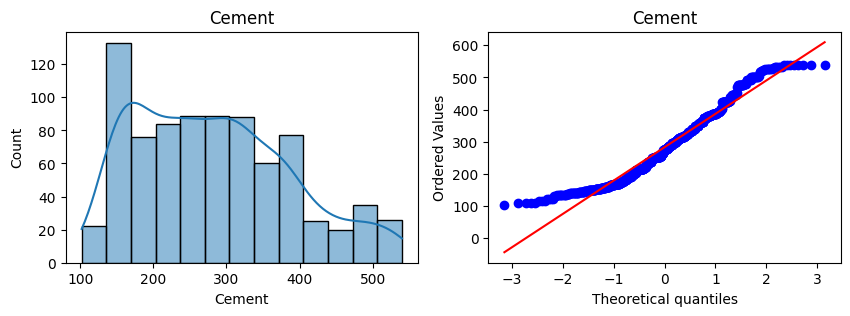

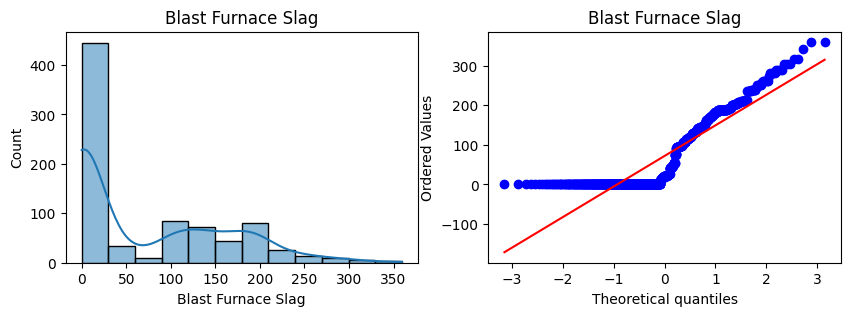

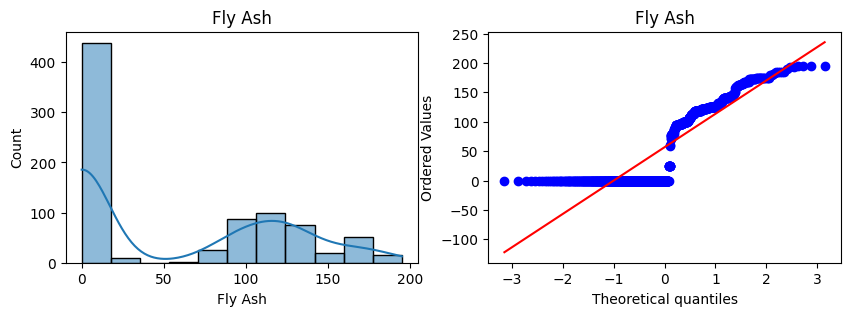

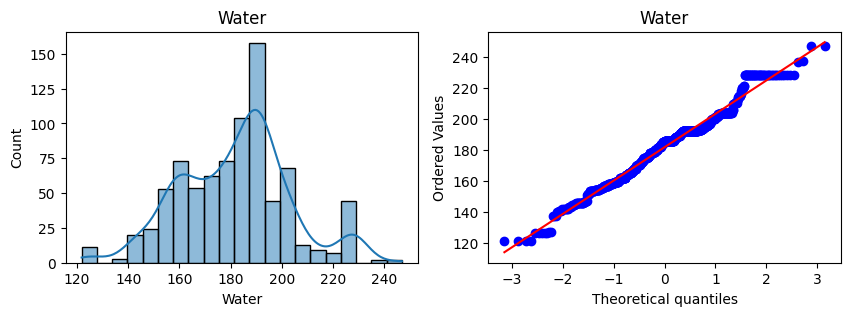

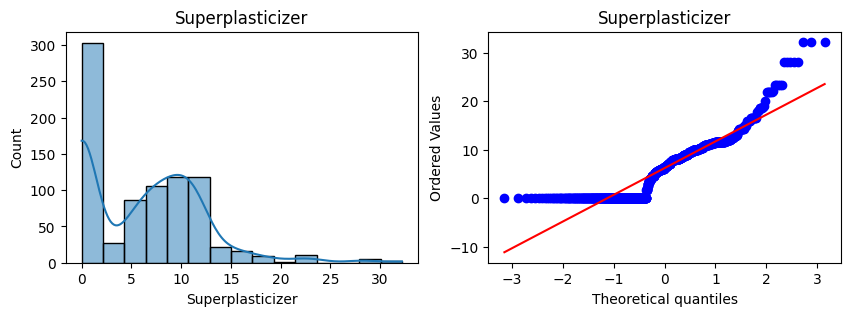

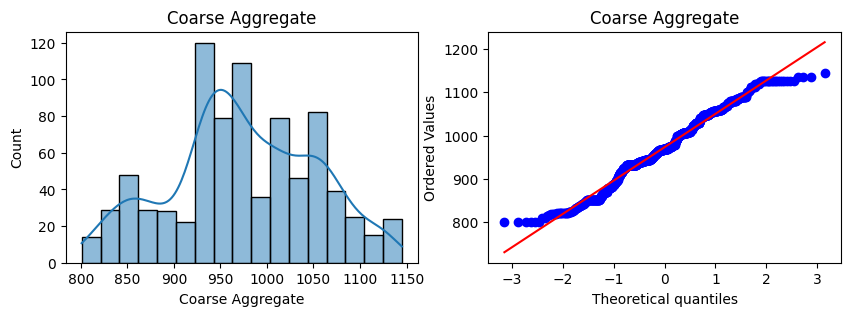

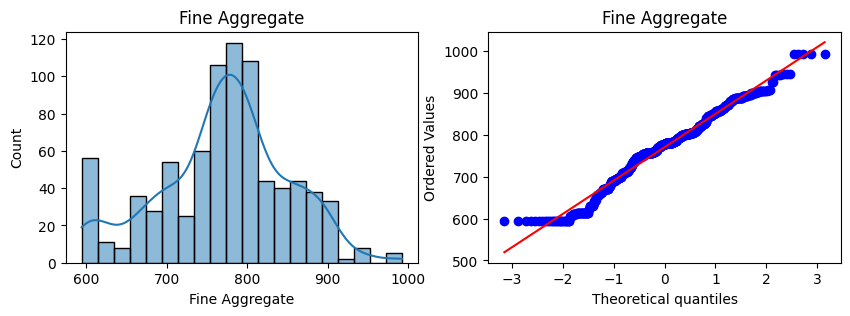

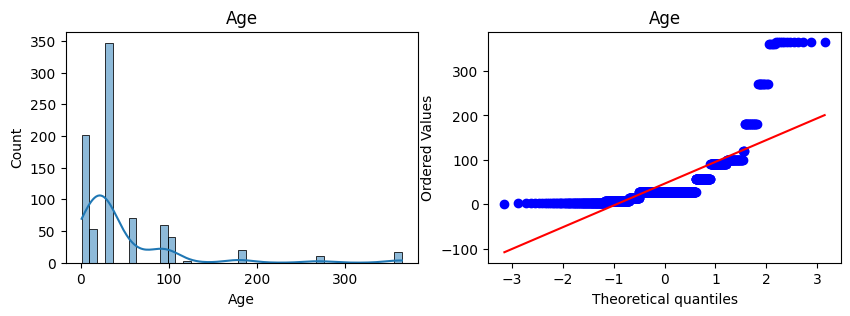

In [40]:
# Plotting the distplot without any transformation
for col in x_train.columns:
    fig, axes = plt.subplots(1,2, figsize=(10,3))

    sns.histplot(x_train[col], kde=True, ax=axes[0])
    axes[0].set_title(col)

    stats.probplot(x_train[col], dist='norm', plot=axes[1])
    axes[1].set_title(col)

    plt.show()

### Applying Box-Cox Transformation

In [42]:
pt = PowerTransformer(method='box-cox')

In [46]:
x_train_transformed = pt.fit_transform(x_train+0.000001)
x_test_transformed = pt.fit_transform(x_test+0.000001)

In [47]:
pd.DataFrame({'cols':x_train.columns, 'box-cox-lambdas':pt.lambdas_})

,cols,box-cox-lambdas
0,Cement,0.227636
1,Blast Furnace Slag,0.051441
2,Fly Ash,-0.078307
3,Water,0.732489
4,Superplasticizer,0.075700
5,Coarse Aggregate,0.503831
6,Fine Aggregate,2.349745
7,Age,0.069189


### Apply Linear Regression on transformed data

In [48]:
lr = LinearRegression()
lr.fit(x_train_transformed, y_train)
y_pred2 = lr.predict(x_test_transformed)
print(r2_score(y_pred2, y_test))

0.740097569269049


In [53]:
# Cross checking with ccross val score
pt = PowerTransformer(method='box-cox')
x_transformed = pt.fit_transform(x+0.000001)
np.mean(cross_val_score(lr, x_transformed, y, cv=8, scoring='r2'))

np.float64(0.6723229563126765)

#### Before and After transformation, comparison of box-cox plot

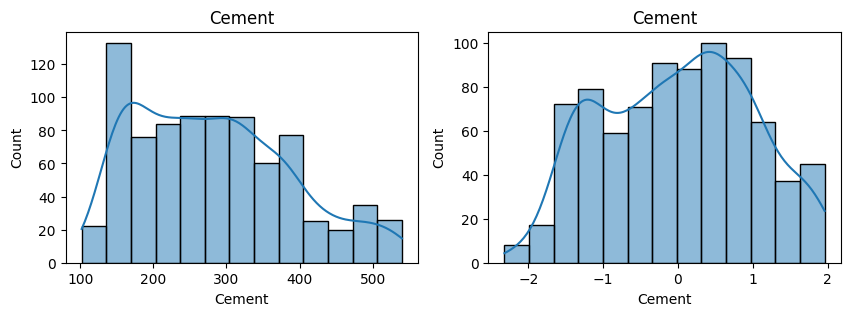

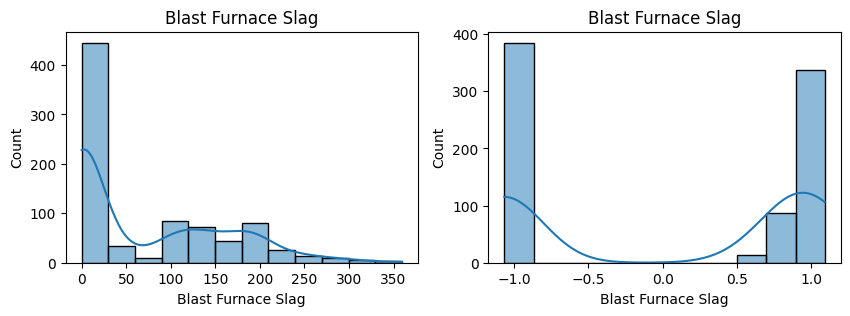

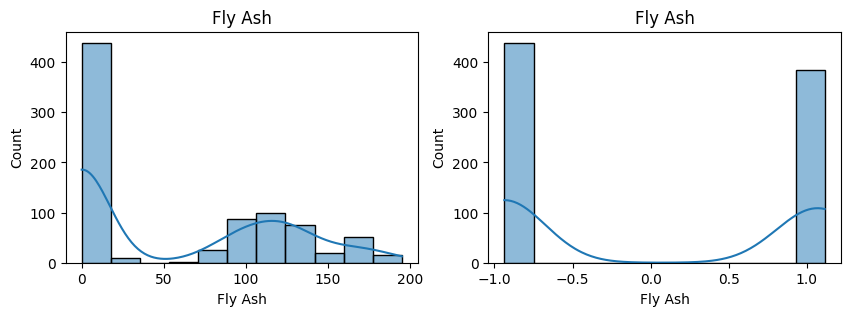

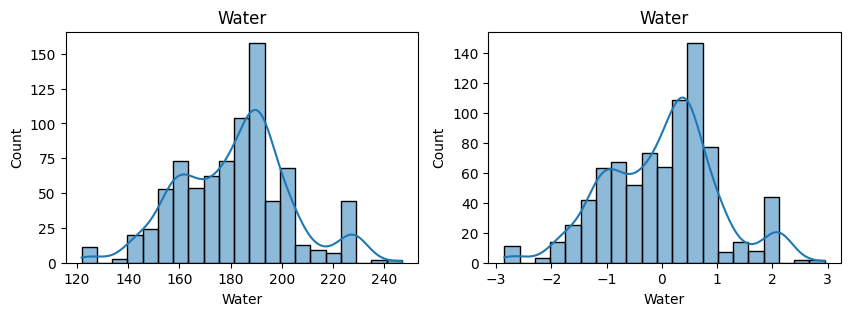

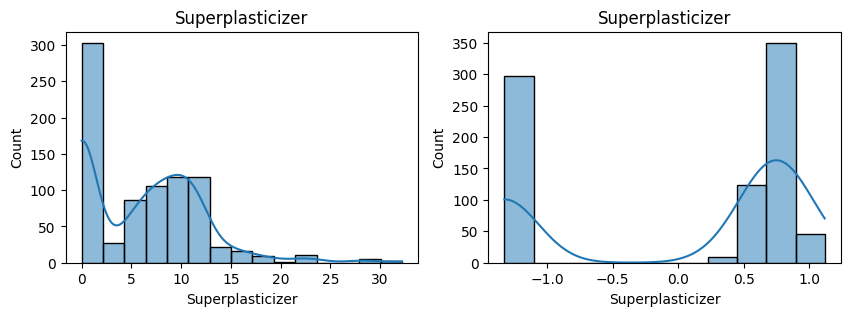

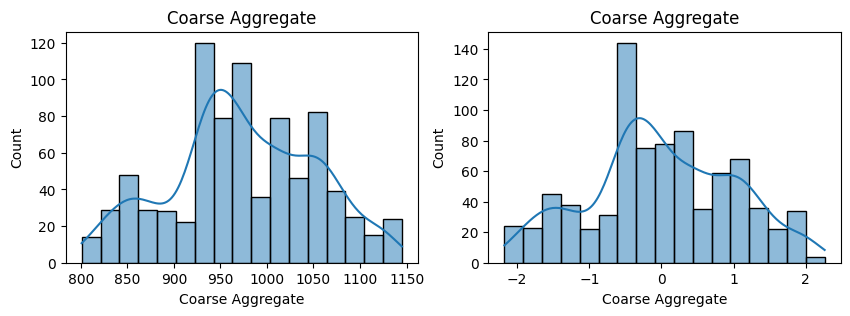

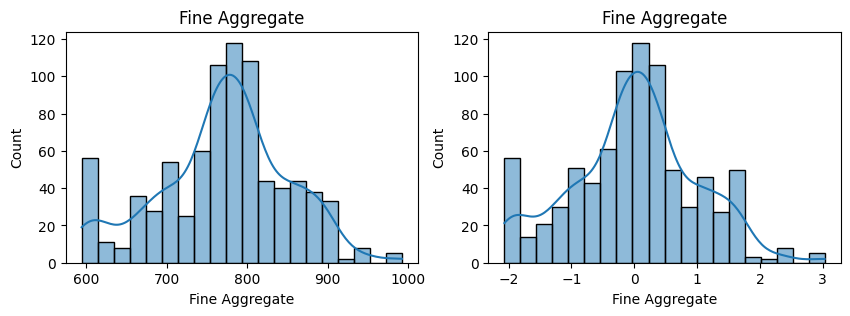

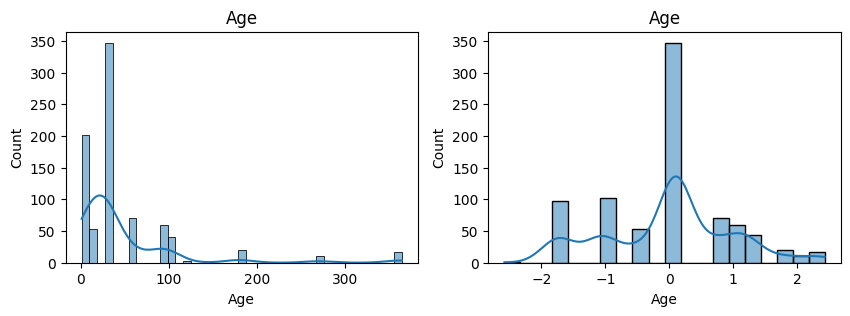

In [54]:
x_train_transformed = pd.DataFrame(x_train_transformed, columns=x_train.columns)

for col in x_train_transformed.columns:
    fig, axes = plt.subplots(1,2, figsize=(10,3))

    sns.histplot(x_train[col], kde=True, ax=axes[0])
    axes[0].set_title(col)

    sns.histplot(x_train_transformed[col], kde=True, ax=axes[1])
    axes[1].set_title(col)

    plt.show()

### Apply Yeo-Johnson transformation

In [55]:
pt2 = PowerTransformer()

x_train_transformed2 = pt2.fit_transform(x_train)
x_test_transformed2 = pt2.fit_transform(x_test)

lr2 = LinearRegression()
lr2.fit(x_train_transformed2, y_train)

y_pred2 = lr2.predict(x_test_transformed2)

print(r2_score(y_pred2, y_test))

0.7407289490518918


In [59]:
x_transformed2 = pt2.fit_transform(x)
cross_val_score(lr2, x_transformed2, y, cv=10, scoring='r2').mean()

np.float64(0.6586548619389643)

In [60]:
pd.DataFrame({'cols':x_train.columns, 'yeo_johnson_lambdas':pt2.lambdas_})

,cols,yeo_johnson_lambdas
0,Cement,0.169544
1,Blast Furnace Slag,0.016633
2,Fly Ash,-0.136480
3,Water,0.808438
4,Superplasticizer,0.264160
5,Coarse Aggregate,1.129395
6,Fine Aggregate,1.830764
7,Age,0.001771


#### Comparison of columns after yeo-johnson transformation

In [61]:
x_train_transformed2 = pd.DataFrame(x_train_transformed2, columns=x_train.columns)

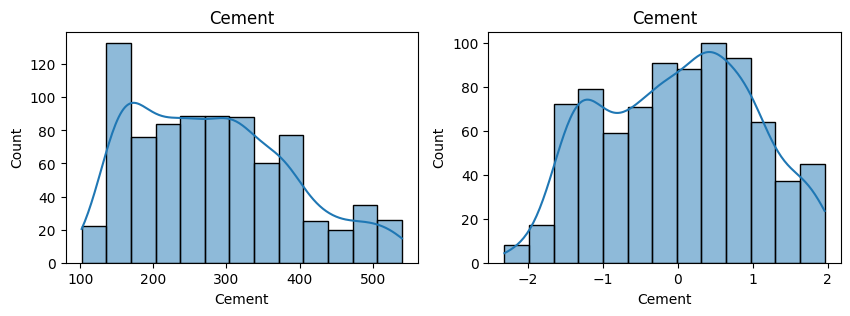

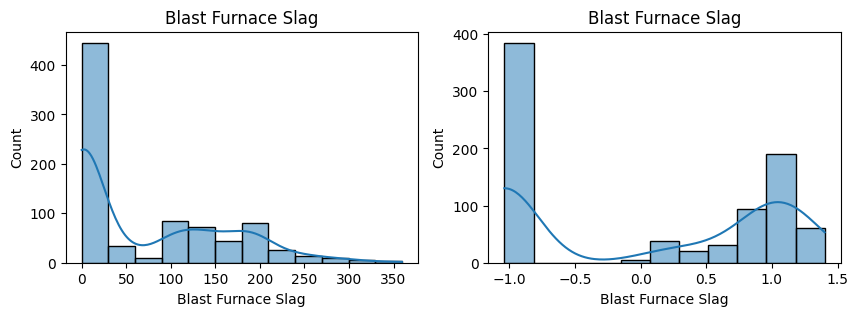

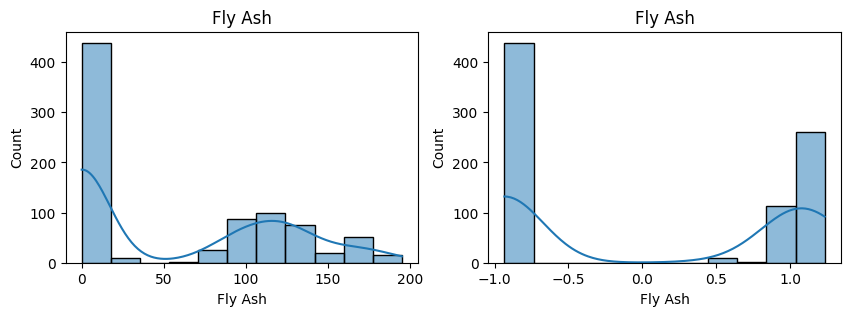

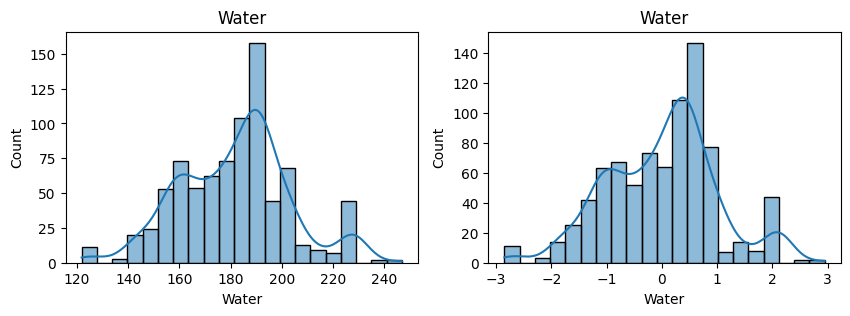

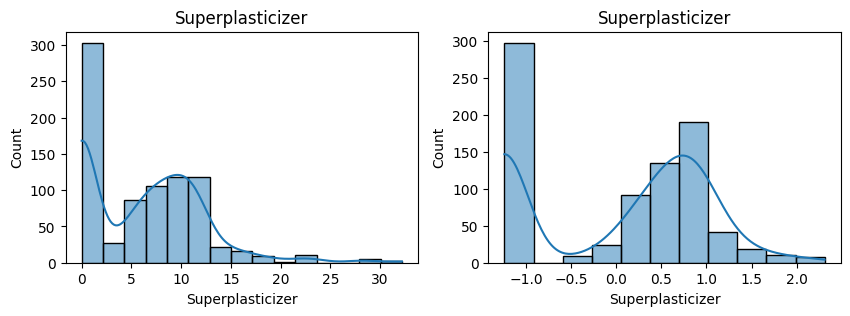

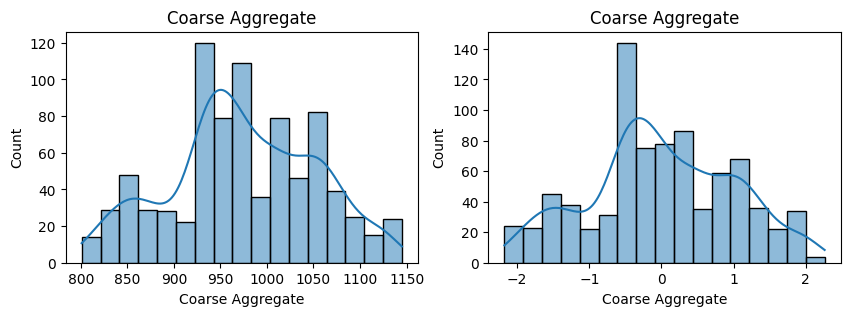

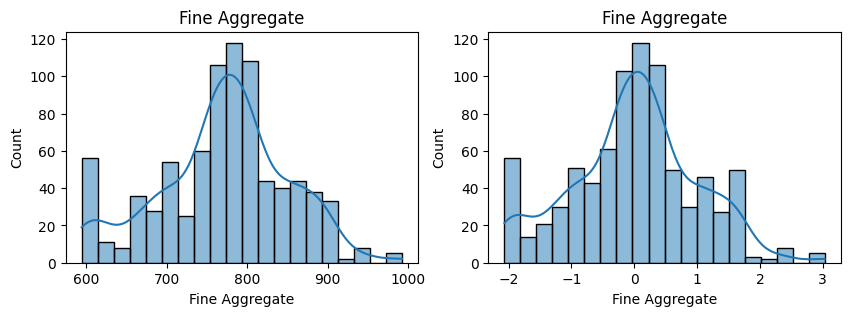

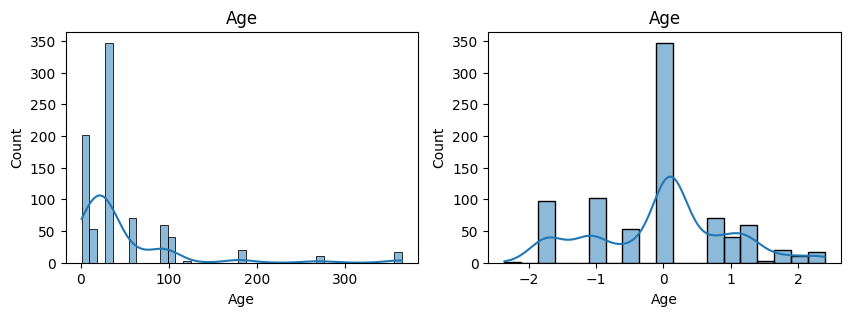

In [64]:
for col in x_train_transformed2.columns:
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,3))

    sns.histplot(x_train[col], kde=True, ax=ax1)
    ax1.set_title(col)
    
    sns.histplot(x_train_transformed2[col], kde=True, ax=ax2)
    ax2.set_title(col)

    plt.show()

In [66]:
# Lambdas Comparison

pd.DataFrame({'cols':x_train.columns, 'box_cox_lambdas':pt.lambdas_, 'yeo_johnson_lambdas':pt2.lambdas_})

,cols,box_cox_lambdas,yeo_johnson_lambdas
0,Cement,0.172271,0.169544
1,Blast Furnace Slag,0.025273,0.016633
2,Fly Ash,-0.032412,-0.136480
3,Water,0.809568,0.808438
4,Superplasticizer,0.099711,0.264160
5,Coarse Aggregate,1.129168,1.129395
6,Fine Aggregate,1.829625,1.830764
7,Age,0.048975,0.001771
